<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/ML/Forest_Classification_DecisionTreeClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


In [19]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [20]:
m = 1200
tenure   = np.random.randint(1, 72, m)           # місяців з нами
monthly  = np.random.normal(70, 25, m).clip(15, 150)  # щомісячна оплата, $
support  = np.random.poisson(1.5, m)             # звернень у підтримку за рік
age      = np.random.randint(18, 75, m)          # вік клієнта

# Прихована логіка ризику відтоку (модель її не знає):
risk = (
    -0.05 * tenure        # довше з нами → менший ризик
    + 0.02 * monthly      # дорожчий тариф → трохи більший ризик
    + 0.45 * support      # багато звернень у підтримку → більший ризик
    - 0.01 * age          # старші клієнти трохи лояльніші
    + np.random.normal(0, 0.7, m)
)
prob = 1 / (1 + np.exp(-(risk - 0.5)))   # перетворюємо ризик на ймовірність 0..1
churn = (np.random.rand(m) < prob).astype(int)

df = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1),
    "support": support, "age": age, "churn": churn,
})

print("Частка клієнтів, що пішли:", f"{df['churn'].mean():.1%}")
df.head()

Частка клієнтів, що пішли: 39.3%


,tenure,monthly,support,age,churn
0,52,21.7,1,21,0
1,15,39.8,1,20,0
2,61,43.2,4,73,0
3,21,87.1,0,46,1
4,24,65.9,1,69,1


In [21]:
df.columns

Index(['tenure', 'monthly', 'support', 'age', 'churn'], dtype='object')

In [22]:
#X = df[['tenure', 'monthly', 'support', 'age']] # features
X = df[['tenure', 'monthly', 'support', 'age']] # features
y = df["churn"] # target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y )# for рівномірного поділу

print("Навчальна вибірка", X_train.shape, "\n", "Тестова вибірка", X_test.shape)

Навчальна вибірка (960, 4) 
 Тестова вибірка (240, 4)


# Design Tree

In [23]:
df.shape

(1200, 5)

In [24]:
y_train.head()


,churn
399,1
1197,0
735,0
547,0
207,0


In [25]:
y_test.head()

,churn
382,0
241,1
7,0
1071,0
1172,0


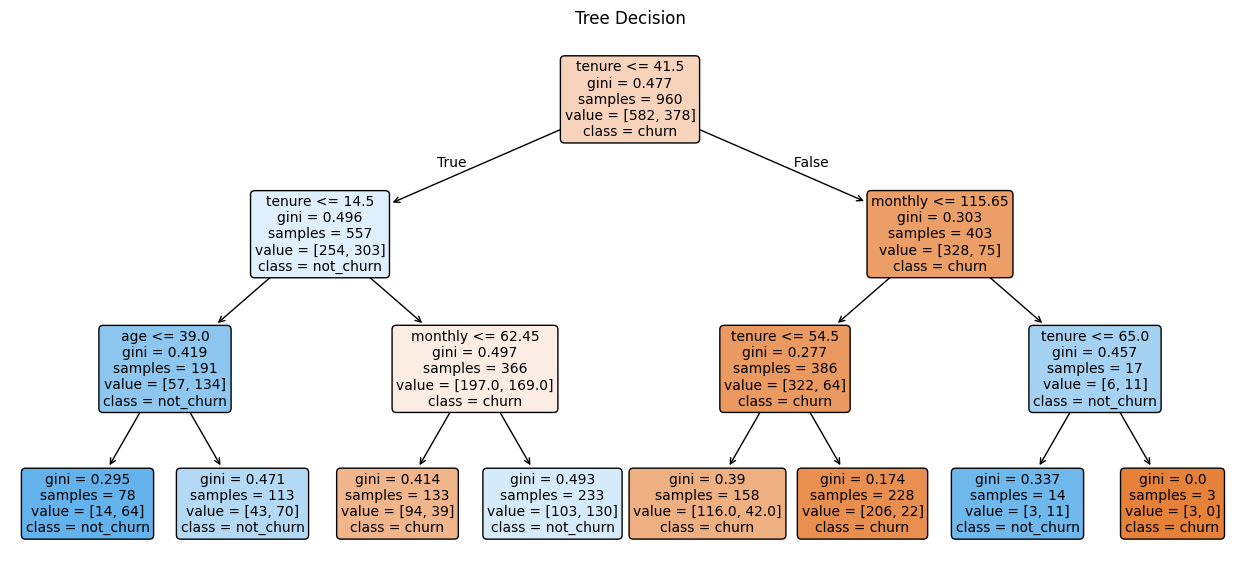

In [43]:
from sklearn.tree import DecisionTreeClassifier
model_tree = DecisionTreeClassifier(
    max_depth=3,random_state=RANDOM_STATE) # обмежуємо її до 3 - х основних питань + задаємо рандомні значення для моделювання
model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)

compare = pd.DataFrame({
    "Actual": y_test[:5].round(),
    "Predicted": y_pred[:5].round()

})
compare["error"] = compare["Actual"] - compare["Predicted"]
compare

plt.figure(figsize=(16,7))
plot_tree(model_tree, feature_names=X.columns, class_names=["churn", "not_churn"], filled=True, rounded=True, fontsize=10) #, impurity=False)
plt.title("Tree Decision")
plt.show()



In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
acc = accuracy_score(y_test, y_pred)
print("Точність моделі:", f"{acc:.1%}")
con_matrix = confusion_matrix(y_test, y_pred)
df_cv = pd.DataFrame(con_matrix,
                     index=["Real churn", "Real not churn"],
                     columns=["Predicted churn", "Predicted not churn"])
df_cv
# 85 та 57 - вгадані
# 37 and 61 не вгадані
#pr # - вгадала
# recall - скільки охоплено данних
print(classification_report(y_test, y_pred, target_names=["Charn", "Not_charn"]))

Точність моделі: 59.2%
              precision    recall  f1-score   support

       Charn       0.70      0.58      0.63       146
   Not_charn       0.48      0.61      0.54        94

    accuracy                           0.59       240
   macro avg       0.59      0.59      0.59       240
weighted avg       0.61      0.59      0.60       240



In [ ]:
# Randomforest Clacifications

In [29]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
model_forest = RandomForestClassifier(n_estimators=200,
                                       max_depth=6,
                                       random_state=RANDOM_STATE)
model_forest.fit(X_train, y_train) # тренування
y_pred_rf = model_forest.predict(X_test) # підставляє дані з тестових данних
acc = accuracy_score(y_test, y_pred_rf) #
acc_t = accuracy_score(y_test, y_pred)  #
print("Точність моделі:", f"{acc:.1%}") # для лісу
print("Точність лісу:", f"{acc_t:.1%}") # для 1 дерева

Точність моделі: 64.6%
Точність лісу: 59.2%


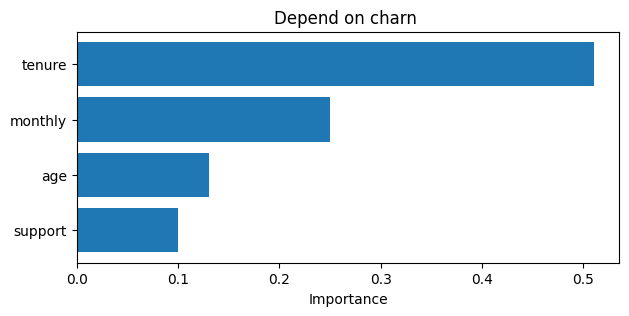

,feature,importance
2,support,0.10
3,age,0.13
1,monthly,0.25
0,tenure,0.51


In [42]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": model_forest.feature_importances_.round(2)
}).sort_values("importance", ascending=True)
plt.figure(figsize=(7,3))
plt.barh(importances["feature"], importances["importance"])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.title("Depend on charn ")

plt.show()
display(importances)

# Прихована логіка ризику відтоку (модель її не знає):
risk = (
    -0.05 * tenure          # довше з нами → менший ризик
    + 0.02 * monthly        # дорожчий тариф → трохи більший ризик
    + 0.45 * support        # багато звернень у підтримку → більший ризик
    - 0.01 * age            # старші клієнти трохи лояльніші
      + np.random.normal(0, 0.7, m)
)